# The Long-term Effect of Africa's Slave Trades on Industrialization

**Ming Chieh Chang** (jay20020713@gmail.com)

In this coding sample, I use Python to replicate the results from my working paper, _"The Long-term Impact of the Historical Slave Trade in Africa on Contemporary Industrialization,"_ which was originally conducted using STATA.

This working paper was developed under the supervision of Professor J. Bradford DeLong at the University of California, Berkeley. I translated the analysis into Python as part of the final project for Professor Bryan S. Graham’s course, _Econometrics: Advanced Methods and Applications_, to demonstrate my proficiency in Python programming and my ability to apply advanced econometric methods using multiple software platforms.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
data = '/Users/changjay/Desktop/Econometrics-Advanced Methods and Applications/Final Project/'

## Load and Organize Data

I utilize the slave trade dataset provided in Nunn (2008) from its [online replication package](https://nathannunn.sites.olt.ubc.ca/files/2022/02/DATA-22The-Long-Term-Effects-of-Africas-Slave-Trades22-slave_trade_qje_replication_dataset.zip). Other than the country-level number of slaves exported, this dataset also encompasses geographical, climatic, and historical economic development variables, which will serve as observable control variables in the subsequent analysis. Additionally, the dataset contains the instrumental variables, specifically the historical distances from each country to the ports from which slaves were exported. 

As for the data pertaining to the level of industrialization in 2000, I use the share of workers in industrial sectors in 2000 from the World Development Indicators compiled by the World Bank. The data can be accessed [here](https://databank.worldbank.org/source/world-development-indicators). 

In [14]:
# Load datasets
slavetrade = pd.read_csv(data + 'Nathan_slavetrade.csv')
wb = pd.read_csv(data + 'world_bank_indicators.csv')

In [15]:
# Merge the two dataset
slavetrade = slavetrade.merge(wb, left_on='country', right_on='country', suffixes=(False, False))

## Initial Explorations to The Data

I start by checking the distribution of our variables of interest. First I present the summary statistics of them and draw the distribution of the dependent and independent variables. 

In [16]:
# Summary statistics
slavetrade[['indemp2000', 'ln_export_area', 'atlantic_distance_minimum', 'indian_distance_minimum', 'saharan_distance_minimum', 'red_sea_distance_minimum']].describe()

,indemp2000,ln_export_area,atlantic_distance_minimum,indian_distance_minimum,saharan_distance_minimum,red_sea_distance_minimum
count,51.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,12.815312,3.259615,7.380800,6.934245,3.511205,3.445517
std,8.218661,3.894839,3.280256,4.238689,1.567817,1.466612
min,2.253780,-2.302585,3.646842,0.031910,0.309734,0.064390
25%,6.838153,-1.104635,5.072046,2.667340,2.733061,2.283090
50%,11.316130,4.370506,5.699416,8.145161,3.355966,3.521949
75%,16.836635,6.555175,9.797528,9.537068,4.681708,4.459597
max,39.251760,8.818254,16.392658,16.775434,6.637325,6.465437


As indicated in the table, there is a significant amount of variation (see std) in the variables of interest. Below are descriptions of these variables:

* indemp2000: Dependent variable, the share of employment in industrial sectors in 2000.
* ln_export_area: Independent variable, log number of slaves exported normalized by land area
* atlantic_distance_minimum, indian_distance_minimum, saharan_distance_minimum, red_sea_distance_minimum: Instrumental variables, minimum distances to the ports from which the slaves were exported during the four slave trading events

The distribution plots of the dependent variable 'indemp2000' and the independent variable 'ln_export_area' are provided below to visualize their distributions.

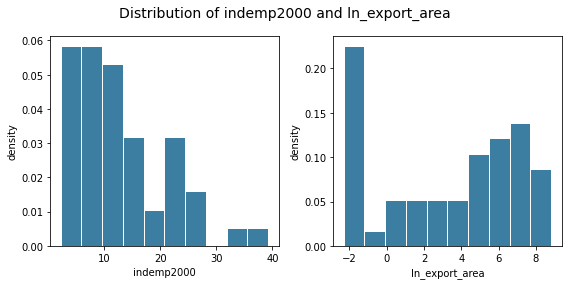

In [17]:
fig_distribution, sbp = plt.subplots(ncols=2, figsize=(8, 4))
ax0 = sbp[0]
ax1 = sbp[1]
fig_distribution.suptitle('Distribution of indemp2000 and ln_export_area', fontsize=14)

# indemp2000
ax0.set_xlabel(r'indemp2000')
ax0.set_ylabel(r'density')
s = ax0.hist(slavetrade['indemp2000'], color = '#3B7EA1',edgecolor = 'white', density=True)
# Instead of frequency, I set density=True to make the Y-axis density. 

# ln_export_area
ax1.set_xlabel(r'ln_export_area')
ax1.set_ylabel(r'density')
s = ax1.hist(slavetrade['ln_export_area'], color = '#3B7EA1',edgecolor = 'white', density=True)

fig_distribution.tight_layout()
plt.show()

Next I show the correlation between the dependent variable indemp2000 and the independent variable ln_export_area in the following scatter plot with a fitted line. 

In [18]:
import statsmodels.api as sm
# I conduct OLS using statsmodels package for its extensive post-estimation tools. 

slavetrade['constant'] = 1 # add constant term
Y = slavetrade['indemp2000']
X = slavetrade[['ln_export_area', 'constant']]

model = sm.OLS(Y, X, missing='drop') # drop observations with any NaN value
regr = model.fit(cov_type='HC1')
# Allow heteroskedasticity by specifying cov_type='HC1', 
# though this doesn't really matter when what we need is just the coefficients. 

Text(0, 0.5, 'Share of Employment in Industrial Sectors in 2000')

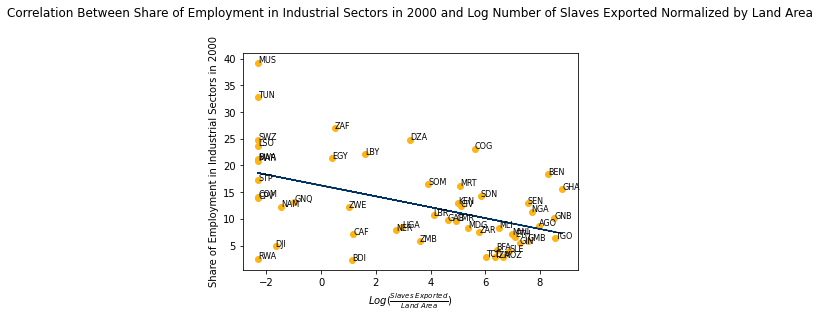

In [19]:
Y_pred = regr.predict(X) # get the predicted values

plt.scatter(X['ln_export_area'], Y, color="#FDB515")
plt.plot(X['ln_export_area'], Y_pred, color="#003262", linewidth=1)

# Mark the name of countries on the graph
n = slavetrade['isocode']
for i, txt in enumerate(n): 
    plt.annotate(txt, (X['ln_export_area'][i], Y[i]), fontsize=8)

plt.title('Correlation Between Share of Employment in Industrial Sectors in 2000 and Log Number of Slaves Exported Normalized by Land Area\n\n')
plt.xlabel(r'$Log(\frac{Slaves\ Exported}{Land\ Area})$')
plt.ylabel('Share of Employment in Industrial Sectors in 2000')

Clearly, there is a negative correlation between the dependent variable 'indemp2000' and the independent variable 'ln_export_area,' providing us with an initial understanding of how the level of industrialization could be influenced by historical slave trades.

However, correlation alone does not establish causality. There may be omitted variables that simultaneously affect both 'indemp2000' and 'ln_export_area,' which underscores the need to include more controls in the regression and the instrumental variable regression. For instance, the intensity of slave trades might be higher in certain countries within specific geographical areas, and industrialization could be influenced by such geographical characteristics. In this scenario, the correlation between 'indemp2000' and 'ln_export_area' actually reflects the impact of these geographical characteristics on industrialization.

# OLS Regressions

Now I formally estimate the equation

$$\text{share industry}_c = \beta_0 + \beta_1 \text{ln(slaves exported/land area)}_c + \mathbf{colony}^{'}_c \delta + \mathbf{geo}^{'}_c \gamma + \varepsilon_c$$

where $\text{share industry}_c$ is the share of employment in industrial secotors in country $c$ in year 2000 (indemp2000). 
$\text{ln(slaves exported/land area)}_c$ represents the natural log of the total number of slaves exported from 1400 to 1900 normalized by land area (ln_export_area). 
$\mathbf{colony}^{'}_c$ constitutes a vector of dummy variables indicating the colonizer before the independence. 
$\mathbf{geo}^{'}_c$ is a vector of geographical and climatic controls, including absolute latitude (i.e. distance from the equator), 
longitude, minimum monthly rainfall, average maximum humidity, average minimum temperature, and proximity to the ocean measured by the natural log of coastline divided by land area. 


To check if omitted variables serverly bias my estimates, I gradually add controls and summarize the results in the table below. 

In [20]:
import statsmodels.api as sm
from stargazer.stargazer import Stargazer
# This package provides easy ways to summarize results from multiple regressions

### OLS without control
Y = slavetrade['indemp2000']
X = slavetrade[['constant', 'ln_export_area']]
model = sm.OLS(Y, X, missing='drop')
OLS1regr = model.fit(cov_type='HC1')
# print(OLS1regr.summary())

### OLS with colonizer dummies
X = slavetrade[['constant', 'ln_export_area', 'colony0', 'colony1', 'colony2', 'colony3', 'colony4', 'colony5', 'colony6']]
# Colonizer dummies are added
model = sm.OLS(Y, X, missing='drop')
OLS2regr = model.fit(cov_type='HC1')
# print(OLS2regr.summary())

### OLS with colonizer dummies and geographical variables
X = slavetrade[['constant', 'ln_export_area', 'colony0', 'colony1', 'colony2', 'colony3', 'colony4', 'colony5', 'colony6', 'abs_latitude', 'longitude', 'rain_min', 'humid_max', 'low_temp', 'ln_coastline_area']]
# Geographical and climatic controls are added
model = sm.OLS(Y, X, missing='drop')
OLS3regr = model.fit(cov_type='HC1')
# print(OLS3regr.summary())

OLSregr = Stargazer([OLS1regr, OLS2regr, OLS3regr])
OLSregr.covariate_order(['ln_export_area', 'colony0', 'colony1', 'colony2', 'colony3', 'colony4', 'colony5', 'colony6', 'abs_latitude', 'longitude', 'rain_min', 'humid_max', 'low_temp', 'ln_coastline_area', 'constant'])
OLSregr.title('OLS Regression')
OLSregr

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/statsmodels/base/model.py:1871: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 6
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/statsmodels/base/model.py:1871: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 14, but rank is 12
  warnings.warn('covariance of constraints does not have full '


As demonstrated in the table above, the OLS coefficients on 'ln_export_area' are significantly negative across columns, indicating the robustness of my results to the inclusion of controls and suggesting that the correlation is not heavily influenced by omitted variable bias. This implies that either these control variables are not significantly correlated with the number of slaves traded, or they do not correlate significantly with the level of industrialization, or both. Consequently, my estimates are more likely to be causal. 

However, there may still be concerns regarding unobserved variables that are not fully accounted for by the inclusion of controls. Therefore, we proceed to conduct instrumental variable regressions as follows. 

## Instrumental Variable Regressions
We now re-estimate the equation mentioned above, instrumenting 'ln_export_area' with four distance variables. These variables indicate the minimum distances from each country to the ports where slaves were exported in the four major slave trading events: the trans-Atlantic, trans-Saharan, Red Sea, and Indian Ocean slave trades. 

These distances serve as valid instrumental variables under the assumption that the demand for slaves is higher in areas closer to the slave-exporting ports, and that this demand is not affected by other factors such as the prosperity of slave-supplying countries. In other words, the distances to ports only affect the level of industrialization nowadays through the slave exports, thereby satisfying the exclusion restriction. Following the format in the OLS table, I present the results in the table below. 

In [21]:
from linearmodels import IV2SLS
# I use the linearmodels package to conduct IV regression for its credibility. 
from pystout import pystout
# This package provides LaTex regression outputs. 

slavetrade = slavetrade.dropna(subset=['indemp2000']) 
# drop observations NaN in variable indemp2000

# IV without control
Y = slavetrade['indemp2000']
X = slavetrade[['constant', 'ln_export_area']]
ins = slavetrade[['atlantic_distance_minimum', 'indian_distance_minimum', 'saharan_distance_minimum', 'red_sea_distance_minimum']] # Instruments
model = IV2SLS(Y, X['constant'], X['ln_export_area'], ins)
IV1regr = model.fit()
# print(IV1regr.summary)

# IV with colonizer dummies
Y = slavetrade['indemp2000']
X = slavetrade[['constant', 'ln_export_area', 'colony0', 'colony1', 'colony2', 'colony3', 'colony4', 'colony5', 'colony6']]
ins = slavetrade[['atlantic_distance_minimum', 'indian_distance_minimum', 'saharan_distance_minimum', 'red_sea_distance_minimum']]
model = IV2SLS(Y, X[['constant', 'colony0', 'colony1', 'colony2', 'colony3', 'colony4', 'colony5', 'colony6']], X['ln_export_area'], ins)
IV2regr = model.fit()
# print(IV2regr.summary)

# IV with colonizer dummies
Y = slavetrade['indemp2000']
X = slavetrade[['constant', 'ln_export_area', 'colony0', 'colony1', 'colony2', 'colony3', 'colony4', 'colony5', 'colony6', 'abs_latitude', 'longitude', 'rain_min', 'humid_max', 'low_temp', 'ln_coastline_area']]
ins = slavetrade[['atlantic_distance_minimum', 'indian_distance_minimum', 'saharan_distance_minimum', 'red_sea_distance_minimum']]
model = IV2SLS(Y, X[['constant', 'colony0', 'colony1', 'colony2', 'colony3', 'colony4', 'colony5', 'colony6', 'abs_latitude', 'longitude', 'rain_min', 'humid_max', 'low_temp', 'ln_coastline_area']], X['ln_export_area'], ins)
IV3regr = model.fit()
# print(IV3regr.summary)

# Summarize regression results into a single LaTex file
pystout(models=[IV1regr, IV2regr, IV3regr],
        file='IVreg.tex',
        digits=4,
        stars={.1:'*', .05:'**', .01:'***'}, 
        modstat={'nobs':'Obs'}
        )

Also we want to check the first-stage regression results corresponding to each instrumental variable regressions, so I estimate the first stage of each IV regression as follows. 

In [22]:
import statsmodels.api as sm
from stargazer.stargazer import Stargazer

# First stage without control
Y = slavetrade[['ln_export_area']]
X = slavetrade[['constant', 'atlantic_distance_minimum', 'indian_distance_minimum', 'saharan_distance_minimum', 'red_sea_distance_minimum']]
model = sm.OLS(Y, X, missing='drop')
FS1regr = model.fit(cov_type='HC1')
# print(FS1regr.summary())

# First stage with colonizer dummies
Y = slavetrade[['ln_export_area']]
X = slavetrade[['constant', 'atlantic_distance_minimum', 'indian_distance_minimum', 'saharan_distance_minimum', 'red_sea_distance_minimum', 'colony0', 'colony1', 'colony2', 'colony3', 'colony4', 'colony5', 'colony6']]
model = sm.OLS(Y, X, missing='drop')
FS2regr = model.fit(cov_type='HC1')
# print(FS2regr.summary())

# First stage with colonizer dummies and geographical variables
Y = slavetrade[['ln_export_area']]
X = slavetrade[['constant', 'atlantic_distance_minimum', 'indian_distance_minimum', 'saharan_distance_minimum', 'red_sea_distance_minimum', 'colony0', 'colony1', 'colony2', 'colony3', 'colony4', 'colony5', 'colony6', 'abs_latitude', 'longitude', 'rain_min', 'humid_max', 'low_temp', 'ln_coastline_area']]
model = sm.OLS(Y, X, missing='drop')
FS3regr = model.fit(cov_type='HC1')
# print(FS3regr.summary())

# Summarize regression results into a single LaTex file to combine with second stage results
FSregr = Stargazer([FS1regr, FS2regr, FS3regr])
FSregr.covariate_order(['atlantic_distance_minimum', 'indian_distance_minimum', 'saharan_distance_minimum', 'red_sea_distance_minimum', 'colony0', 'colony1', 'colony2', 'colony3', 'colony4', 'colony5', 'colony6', 'abs_latitude', 'longitude', 'rain_min', 'humid_max', 'low_temp', 'ln_coastline_area', 'constant'])

file_name = "First-stage.tex"
tex_file = open(file_name, "w")
tex_file.write(FSregr.render_latex())
tex_file.close()

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/statsmodels/base/model.py:1871: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 9
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/statsmodels/base/model.py:1871: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 15
  warnings.warn('covariance of constraints does not have full '


In [23]:
%%latex
\begin{array}{ccc}
    & & IV Regression \\
    &  \\
    \hline
     & (1) & (2) & (3) \\
     & & Dependent\ variable: indemp2000 \\
    \hline
    ln\_export\_area & -2.1518^{***} & -2.0699^{***} & -2.2703^{**} \\
     & (0.5153) & (0.5691) & (0.9659) \\
    \hline
    & & Fisrt\ Stage\ Coefficients \\ 
    \hline
     atlantic\_distance & -1.279^{***} & -1.695^{***} & -1.313^{*} \\
    & (0.348) & (0.447) & (0.784) \\
     indian\_distance & -1.079^{***} & -1.413^{***} & -1.078^{} \\
    & (0.376) & (0.545) & (0.793) \\
     saharan\_distance & -2.372^{***} & -2.929^{***} & -1.145^{} \\
    & (0.815) & (1.104) & (1.867) \\
     red\_sea\_distance & -0.014^{} & -0.136^{} & -1.204^{} \\
    & (0.726) & (0.913) & (1.786) \\
    Colonizer\ dummies &         -   &         \checkmark   &      \checkmark \\
    Geography\ controls &         -   &         -   &      \checkmark \\
    \hline
    Obs & 51 & 51 & 51 \\
    \hline\hline
\end{array}

<IPython.core.display.Latex object>

As evident from the table, the estimated coefficients from the IV regressions remain significantly negative across all columns. The first stage coefficients are negative and at least the slave trading distance of the biggest slave trade, the Trans-atlantic slave trade, is significant. 

Notably, the magnitude of these coefficients is doubled compared to their corresponding OLS estimates. This discrepancy could arise from unobserved omitted variables. For instance, if slave traders targeted countries with weaker local governance, and if weaker local governance at that time is negatively correlated with industrialization later on, then the OLS estimates might underestimate the true effect. Additionally, measurement error issues could also be resolved in the IV regressions, thus resulting in a larger magnitude. Hence, if anything, the OLS estimates may actually underestimate the impact of slave trades on industrialization. 

In sum, both the OLS and IV regressions suggest a negative causal relationship between slave trades and country-level industrialization, persisting even hundreds of years later. 